# Exploratory Data Analysis (EDA) & Preprocessing

This notebook explores and preprocesses the **TCGA PANCAN RNA-Seq gene expression dataset**. The objective is to examine the characteristics and quality of the dataset and prepare it for subsequent dimensionality reduction and classification analyses.

The notebook consists of two stages.

## Exploratory Data Analysis (EDA)

The exploratory analysis provides an overview of the dataset before preprocessing is performed. The analysis includes:

- Dataset overview
- Data quality assessment
- Class distribution
- Gene-level analysis
- Sample-level analysis
- Correlation overview

## Preprocessing

Based on the findings from the exploratory analysis, preprocessing operations required for downstream analysis are performed. These include:

- Removal of zero-variance genes
- Verification of the processed dataset
- Saving the processed dataset

Feature standardization is intentionally **not** performed in this notebook. Since model evaluation will be carried out using **Repeated Stratified 5-Fold Cross-Validation** with **10 repetitions**, standardization will be fitted separately within each training fold to prevent data leakage.

## Workflow

1. Load the raw gene expression dataset and corresponding class labels.
2. Import the required libraries.
3. Perform an initial overview of the dataset.
4. Assess data quality by checking:
   - Missing values
   - Duplicate samples
   - Alignment between the expression matrix and class labels
5. Perform exploratory data analysis:
   - Summary statistics
   - Class distribution
   - Gene expression distribution
   - Gene-wise variance
   - Sample-wise mean and variance
   - Correlation overview
6. Remove genes with zero variance.
7. Verify the processed dataset:
   - No remaining zero-variance genes
   - No missing values
   - Correct alignment of samples and labels
8. Save the processed dataset for subsequent analyses.

## 1. Data & Imports

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_state = 42

In [2]:
# Define file paths
raw_dir = Path("../data/raw/TCGA-PANCAN-HiSeq-801x20531")
figure_dir = Path("../figures/eda")

figure_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the gene expression dataset and class labels
X = pd.read_csv(raw_dir / "data.csv", index_col=0)
y = pd.read_csv(raw_dir / "labels.csv", index_col=0).iloc[:, 0]

## 2. Dataset Overview

In [4]:
# First few rows of the expression matrix
X.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [5]:
# First few labels
y.head()

sample_0    PRAD
sample_1    LUAD
sample_2    PRAD
sample_3    PRAD
sample_4    BRCA
Name: Class, dtype: str

In [6]:
# Data types
print(f"Expression matrix data type : {X.dtypes.unique()}")
print(f"Label data type             : {y.dtype}")

Expression matrix data type : [dtype('float64')]
Label data type             : str


In [7]:
# Display dataset dimensions and class information
print(f"Expression matrix shape : {X.shape}")
print(f"Label vector shape      : {y.shape}")

n_samples, n_genes = X.shape

print(f"Number of samples : {n_samples}")
print(f"Number of genes   : {n_genes}")
print(f"Number of classes : {y.nunique()}")

print("\nCancer types:")
print(sorted(y.unique()))

Expression matrix shape : (801, 20531)
Label vector shape      : (801,)
Number of samples : 801
Number of genes   : 20531
Number of classes : 5

Cancer types:
['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


In [8]:
# Sample to feature ratio
print(f"Samples : {n_samples}")
print(f"Genes   : {n_genes}")
print(f"p / n   : {n_genes / n_samples:.2f}")

Samples : 801
Genes   : 20531
p / n   : 25.63


## 3. Data Quality Assessment

In [9]:
# Missing values
print(f"Missing values in X : {X.isna().sum().sum()}")
print(f"Missing values in y : {y.isna().sum()}")

Missing values in X : 0
Missing values in y : 0


In [10]:
# Duplicate samples
print(f"Duplicate sample IDs   : {X.index.duplicated().sum()}")
print(f"Duplicate observations : {X.duplicated().sum()}")

Duplicate sample IDs   : 0
Duplicate observations : 0


In [11]:
# Check alignment between X and y
print(f"Sample IDs match: {X.index.equals(y.index)}")

Sample IDs match: True


## 4. Exploratory Analysis

In [12]:
# Summary statistics
X.describe().T

,count,mean,std,min,25%,50%,75%,max
gene_0,801.0,0.026642,0.136850,0.000000,0.000000,0.000000,0.000000,1.482332
gene_1,801.0,3.010909,1.200828,0.000000,2.299039,3.143687,3.883484,6.237034
gene_2,801.0,3.095350,1.065601,0.000000,2.390365,3.127006,3.802534,6.063484
gene_3,801.0,6.722305,0.638819,5.009284,6.303346,6.655893,7.038447,10.129528
gene_4,801.0,9.813612,0.506537,8.435999,9.464466,9.791599,10.142324,11.355621
...,...,...,...,...,...,...,...,...
gene_20526,801.0,11.742228,0.670371,9.045255,11.315857,11.749802,12.177852,13.715361
gene_20527,801.0,10.155271,0.580569,7.530141,9.836525,10.191207,10.578561,11.675653
gene_20528,801.0,9.590726,0.563849,7.864533,9.244219,9.566511,9.917888,12.813320
gene_20529,801.0,5.528177,2.073859,0.593975,4.092385,5.218618,6.876382,11.205836


In [13]:
# Class distribution
class_counts = y.value_counts().sort_index()
print(class_counts)

Class
BRCA    300
COAD     78
KIRC    146
LUAD    141
PRAD    136
Name: count, dtype: int64


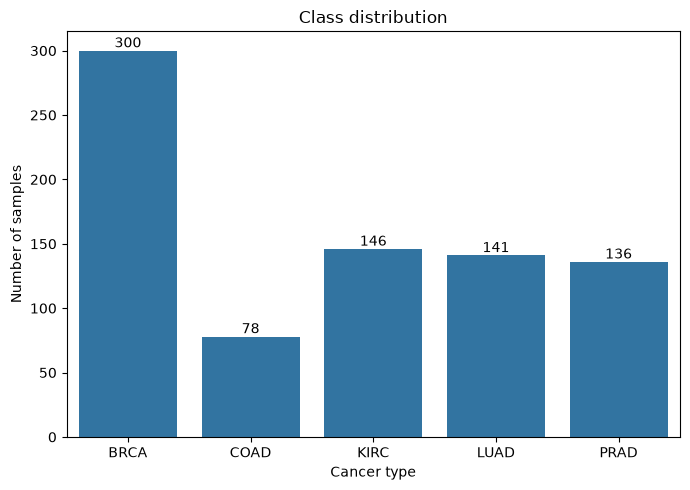

In [14]:
# Plot class distribution
plt.figure(figsize=(7, 5))

ax = sns.countplot(x=y, order=sorted(y.unique()))
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Cancer type")
plt.ylabel("Number of samples")
plt.title("Class distribution")
plt.tight_layout()
plt.savefig(figure_dir / "class_distribution.png", dpi=300)
plt.show()

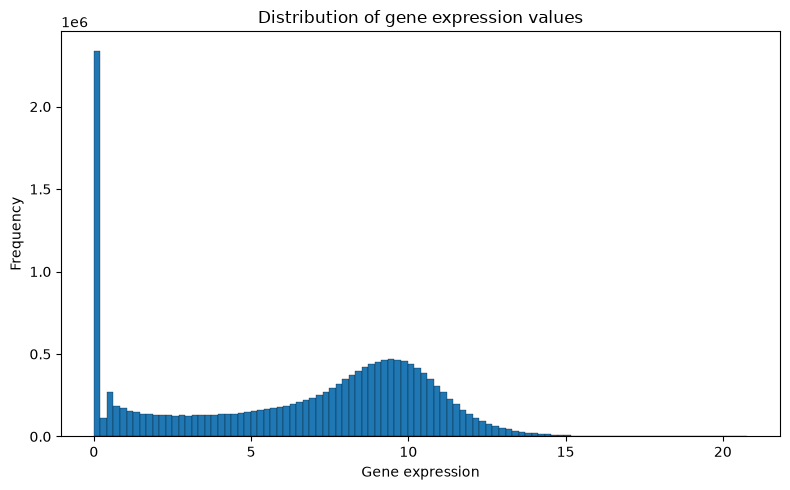

In [15]:
# Gene expression distribution
plt.figure(figsize=(8, 5))

plt.hist(X.to_numpy().ravel(), bins=100, edgecolor="black", linewidth=0.2)

plt.xlabel("Gene expression")
plt.ylabel("Frequency")
plt.title("Distribution of gene expression values")
plt.tight_layout()
plt.savefig(figure_dir / "gene_expression_distribution.png", dpi=300)
plt.show()

In [16]:
# Gene-wise variance
gene_variance = X.var()
print(gene_variance.describe())

count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


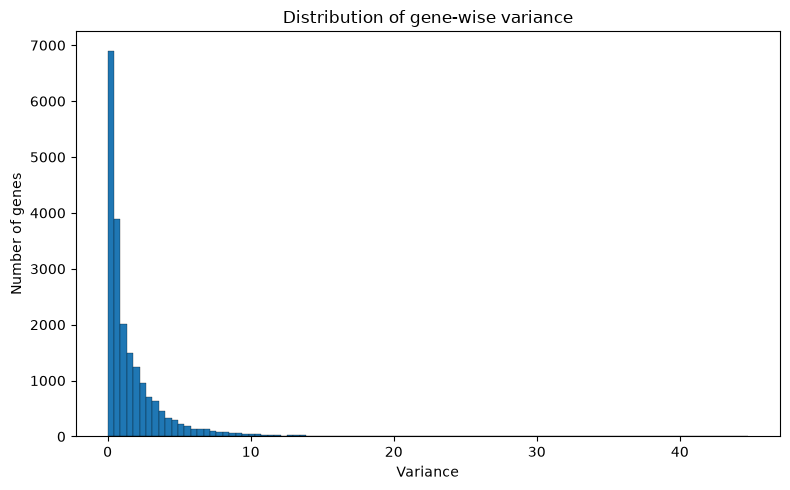

In [17]:
# Distribution of Gene-wise variance
plt.figure(figsize=(8, 5))

plt.hist(gene_variance, bins=100, edgecolor="black", linewidth=0.2)

plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of gene-wise variance")
plt.tight_layout()
plt.savefig(figure_dir / "gene_variance_distribution.png", dpi=300)
plt.show()

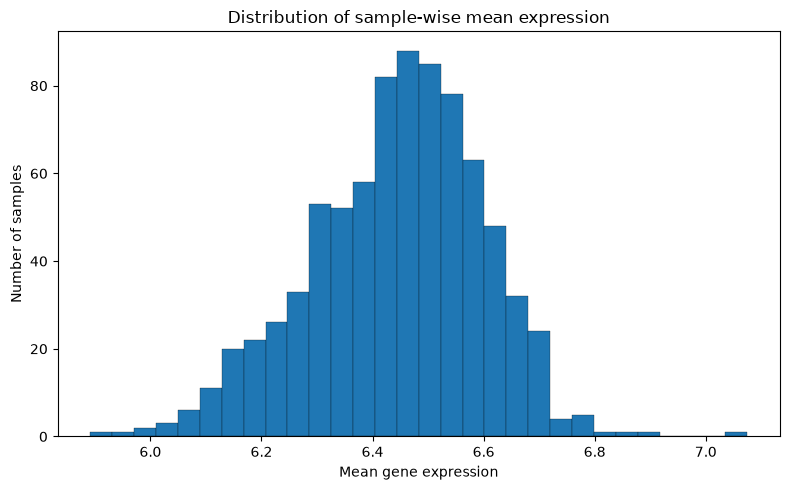

In [18]:
# Sample-wise mean expression
sample_mean = X.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.hist(sample_mean, bins=30, edgecolor="black", linewidth=0.2)

plt.xlabel("Mean gene expression")
plt.ylabel("Number of samples")
plt.title("Distribution of sample-wise mean expression")
plt.tight_layout()
plt.savefig(figure_dir / "sample_mean_distribution.png", dpi=300)
plt.show()

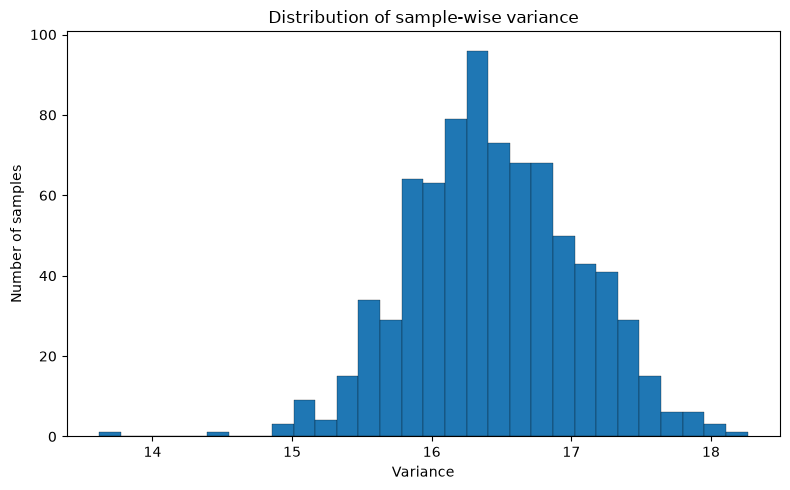

In [19]:
# Sample-wise variance expression
sample_variance = X.var(axis=1)

plt.figure(figsize=(8, 5))

plt.hist(sample_variance, bins=30, edgecolor="black", linewidth=0.2)

plt.xlabel("Variance")
plt.ylabel("Number of samples")
plt.title("Distribution of sample-wise variance")
plt.tight_layout()
plt.savefig(figure_dir / "sample_variance_distribution.png", dpi=300)
plt.show()

A full correlation matrix for all 20,531 genes is computationally expensive and difficult to interpret. Therefore, correlations are examined using a random subset of genes to obtain a representative overview of the correlation structure.

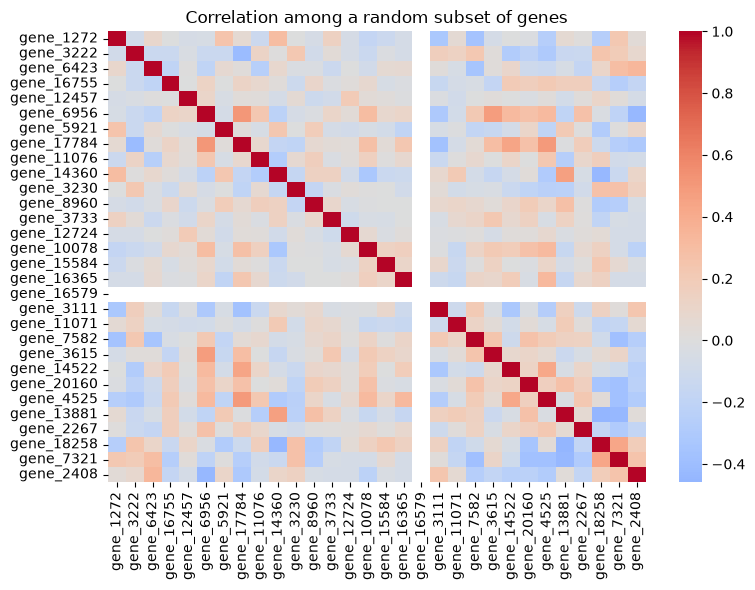

In [20]:
# Correlation among a subset of genes
subset = X.sample(n=30, axis=1, random_state=random_state)

plt.figure(figsize=(8, 6))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Correlation among a random subset of genes")
plt.tight_layout()
plt.savefig(figure_dir / "correlation_heatmap.png", dpi=300)
plt.show()

## 5. Preprocessing

In [21]:
# Paths for processed data
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [22]:
# Compute gene-wise variance
gene_variance = X.var(axis=0)

# Identify zero-variance genes
zero_variance_mask = gene_variance == 0
n_zero_variance = zero_variance_mask.sum()

print(f"Zero-variance genes : {n_zero_variance}")

Zero-variance genes : 267


In [23]:
# Remove zero-variance genes
X_processed = X.loc[:, ~zero_variance_mask]

In [24]:
# Verify preprocessing
remaining_zero_variance = (X_processed.var(axis=0) == 0).sum()

print(f"Samples                     : {X_processed.shape[0]}")
print(f"Original genes              : {X.shape[1]}")
print(f"Removed zero-variance genes : {n_zero_variance}")
print(f"Remaining genes             : {X_processed.shape[1]}")
print(f"Remaining zero-variance     : {remaining_zero_variance}")
print(f"Missing values              : {X_processed.isna().sum().sum()}")
print(f"Sample IDs match            : {X_processed.index.equals(y.index)}")

Samples                     : 801
Original genes              : 20531
Removed zero-variance genes : 267
Remaining genes             : 20264
Remaining zero-variance     : 0
Missing values              : 0
Sample IDs match            : True


In [25]:
# Save processed dataset
X_processed.to_csv(processed_dir / "X_processed.csv")
y.to_csv(
    processed_dir / "y_processed.csv",
    header=True
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
